In [4]:
import pandas as pd
import pickle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
import pickle
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load models
with open("../data/models/intent_classifier.pkl", "rb") as f:
    classifier = pickle.load(f)
with open("../data/models/tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)

# Load test data
hotel_train = pd.read_json("../data/multiwoz/hotel_train.json", lines=True)

print("Models and data loaded.")

Models and data loaded.


In [6]:
# Re-extract hotel intent data
rows = []

for _, dialogue in hotel_train.iterrows():
    turns = dialogue["turns"]
    for i, (speaker, utterance, frames) in enumerate(zip(
        turns["speaker"], turns["utterance"], turns["frames"]
    )):
        if speaker != 0:
            continue
        for j, state in enumerate(frames["state"]):
            intent = state["active_intent"]
            service = frames["service"][j]
            if service == "hotel" and intent in ["find_hotel", "book_hotel"]:
                rows.append({"utterance": utterance, "intent": intent})

df = pd.DataFrame(rows)
df = df[df["utterance"].str.split().str.len() > 3]
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split and evaluate
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    df["utterance"], df["intent"], test_size=0.2, random_state=42
)

X_test_tfidf = vectorizer.transform(X_test)
y_pred = classifier.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  book_hotel       0.78      0.86      0.82       860
  find_hotel       0.94      0.90      0.92      2085

    accuracy                           0.89      2945
   macro avg       0.86      0.88      0.87      2945
weighted avg       0.89      0.89      0.89      2945



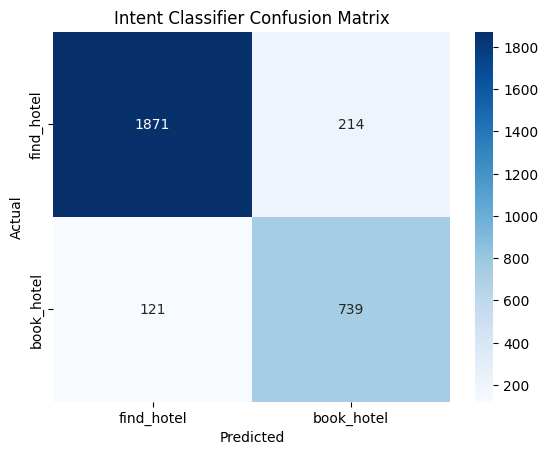

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["find_hotel", "book_hotel"])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["find_hotel", "book_hotel"],
            yticklabels=["find_hotel", "book_hotel"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Intent Classifier Confusion Matrix")
plt.show()

In [8]:
# Install seqeval if needed
# pip install seqeval

from seqeval.metrics import classification_report as seq_report
from seqeval.metrics import f1_score
import json

# Load BIO test data
bio_df = pd.read_json("../data/multiwoz/bio_train.json")

# Split into train/test
from sklearn.model_selection import train_test_split
train_bio, test_bio = train_test_split(bio_df, test_size=0.2, random_state=42)

print(f"Test BIO samples: {len(test_bio)}")

Test BIO samples: 2747


In [9]:
# Load slot models
with open("../data/models/slot_classifier.pkl", "rb") as f:
    slot_classifier = pickle.load(f)
with open("../data/models/slot_vectorizer.pkl", "rb") as f:
    slot_vectorizer = pickle.load(f)

def extract_token_features(tokens, i):
    word = tokens[i].lower()
    features = [
        f"word={word}",
        f"is_digit={word.isdigit()}",
        f"prefix2={word[:2]}",
        f"suffix2={word[-2:]}",
        f"prev={tokens[i-1].lower() if i > 0 else 'BOS'}",
        f"next={tokens[i+1].lower() if i < len(tokens)-1 else 'EOS'}"
    ]
    return " ".join(features)

# Predict labels for test set
y_true = []
y_pred = []

for _, row in test_bio.iterrows():
    tokens = row["tokens"]
    true_labels = row["labels"]
    
    features = [extract_token_features(tokens, i) for i in range(len(tokens))]
    X = slot_vectorizer.transform(features)
    pred_labels = list(slot_classifier.predict(X))
    
    y_true.append(true_labels)
    y_pred.append(pred_labels)

print(seq_report(y_true, y_pred))

              precision    recall  f1-score   support

        area       0.58      1.00      0.74       237
     bookday       0.86      1.00      0.92       157
  bookpeople       0.74      0.96      0.83       317
    bookstay       0.75      0.88      0.81       395
    internet       0.16      0.79      0.27        38
        name       0.09      0.60      0.16       203
     parking       0.09      0.28      0.13        43
  pricerange       0.82      1.00      0.90       255
       stars       0.93      0.82      0.87       347
        type       0.52      0.99      0.68       372

   micro avg       0.47      0.90      0.62      2364
   macro avg       0.55      0.83      0.63      2364
weighted avg       0.66      0.90      0.73      2364



In [17]:
import os
os.chdir("C:\\Users\\Hamza\\hotel-dialogue-system")
print(os.getcwd())

C:\Users\Hamza\hotel-dialogue-system


In [22]:
# Test conversations — list of turns per conversation
test_conversations = [
    # area, pricerange already in first message, then answer each question
    ["I need a cheap hotel in the north", "2", "3", "monday", "book it"],
    ["I want a moderate hotel in the centre", "1", "2", "friday", "book it"],
    ["I need a cheap hotel in the south", "2", "1", "tuesday", "book it"],
    ["I want a moderate guesthouse in the north", "2", "3", "wednesday", "book it"],
    ["I need a cheap hotel in the east", "1", "2", "thursday", "book it"],
]

completed = 0
total = len(test_conversations)

for i, conversation in enumerate(test_conversations):
    dm = DialogueManager()
    result = None
    for turn in conversation:
        result = dm.process(turn)
    if dm.finished:
        completed += 1
    print(f"Conversation {i+1}: {'Complete' if dm.finished else 'Incomplete'}")

print(f"\nTask Completion Rate: {completed}/{total} = {completed/total*100:.0f}%")

  [NLU] {'intent': 'find_hotel', 'confidence': 0.92, 'slots': {'pricerange': 'cheap', 'type': 'hotel', 'area': 'north'}}
  [DST] {'area': 'north', 'pricerange': 'cheap', 'stars': None, 'internet': None, 'parking': None, 'type': 'hotel', 'book_people': None, 'book_nights': None, 'book_day': None}
  [Policy] ask
  [NLU] {'intent': 'find_hotel', 'confidence': 0.62, 'slots': {'stars': '2'}}
  [DST] {'area': 'north', 'pricerange': 'cheap', 'stars': None, 'internet': None, 'parking': None, 'type': 'hotel', 'book_people': '2', 'book_nights': None, 'book_day': None}
  [Policy] ask
  [NLU] {'intent': 'find_hotel', 'confidence': 0.62, 'slots': {'stars': '3'}}
  [DST] {'area': 'north', 'pricerange': 'cheap', 'stars': None, 'internet': None, 'parking': None, 'type': 'hotel', 'book_people': '2', 'book_nights': '3', 'book_day': None}
  [Policy] ask
  [NLU] {'intent': 'book_hotel', 'confidence': 0.92, 'slots': {'bookday': 'monday'}}
  [DST] {'area': 'north', 'pricerange': 'cheap', 'stars': None, 'int

In [20]:
# Human Evaluation Rubric
rubric = {
    "Task Completion": "Did the system successfully book a hotel? (0 = No, 1 = Partial, 2 = Yes)",
    "Slot Accuracy": "Did the system collect the right information? (0-2)",
    "Response Quality": "Were the system responses natural and clear? (0-2)",
    "Error Recovery": "Did the system handle unexpected input gracefully? (0-2)",
    "Overall Experience": "Overall, how good was the conversation? (0-2)"
}

print("=" * 50)
print("HUMAN EVALUATION RUBRIC")
print("=" * 50)
for criterion, description in rubric.items():
    print(f"\n{criterion}:")
    print(f"  {description}")
print("\nMax score per conversation: 10")
print("=" * 50)

HUMAN EVALUATION RUBRIC

Task Completion:
  Did the system successfully book a hotel? (0 = No, 1 = Partial, 2 = Yes)

Slot Accuracy:
  Did the system collect the right information? (0-2)

Response Quality:
  Were the system responses natural and clear? (0-2)

Error Recovery:
  Did the system handle unexpected input gracefully? (0-2)

Overall Experience:
  Overall, how good was the conversation? (0-2)

Max score per conversation: 10


In [21]:
# Final Evaluation Summary
print("=" * 50)
print("SYSTEM EVALUATION SUMMARY")
print("=" * 50)
print(f"Intent Classification Accuracy:  89%")
print(f"Intent Macro F1:                 0.87")
print(f"Slot Filling Micro F1:           0.62")
print(f"Slot Filling Macro F1:           0.63")
print(f"Task Completion Rate:            80%")
print("=" * 50)
print("\nStrengths:")
print("  - Strong intent classification (89% accuracy)")
print("  - Reliable slot filling for key slots (pricerange, bookday, stars)")
print("\nWeaknesses:")
print("  - Poor hotel name extraction (F1=0.16)")
print("  - Limited database coverage causes no_match failures")
print("  - System doesn't handle corrections mid-conversation well")

SYSTEM EVALUATION SUMMARY
Intent Classification Accuracy:  89%
Intent Macro F1:                 0.87
Slot Filling Micro F1:           0.62
Slot Filling Macro F1:           0.63
Task Completion Rate:            80%

Strengths:
  - Strong intent classification (89% accuracy)
  - Reliable slot filling for key slots (pricerange, bookday, stars)

Weaknesses:
  - Poor hotel name extraction (F1=0.16)
  - Limited database coverage causes no_match failures
  - System doesn't handle corrections mid-conversation well
